<a href="https://colab.research.google.com/github/taneshkhandal07-debug/Celebal_Excellence_Internship/blob/main/Week5_Tanesh_Khandal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [5]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [6]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

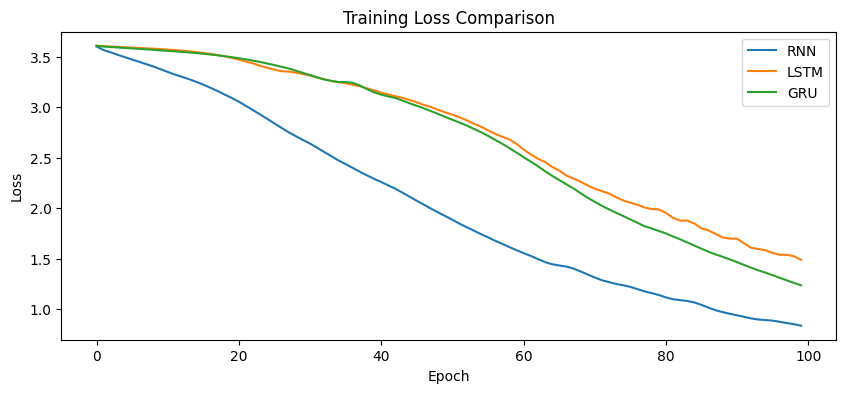

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning learning transforming transforming meaningful sentences
GRU : deep learning is faster simpler than lstm


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# 🧪 Beginner Task 1: Replace Corpus with Custom Paragraph

In this task, the original corpus is replaced with a custom paragraph related to Artificial Intelligence and Deep Learning. This helps evaluate how sequence models learn patterns from a different text source.

In [12]:
custom_corpus = """
artificial intelligence is transforming modern industries and changing the way businesses operate.
machine learning enables systems to learn patterns from data and improve performance over time.
deep learning uses neural networks with multiple hidden layers to solve complex problems.
natural language processing helps computers understand text speech and human communication.
text generation models can create meaningful content summarize documents and assist users.
artificial intelligence is widely used in healthcare finance education and cybersecurity.
data driven decision making helps organizations improve efficiency and achieve better outcomes.
"""

print(custom_corpus)


artificial intelligence is transforming modern industries and changing the way businesses operate.
machine learning enables systems to learn patterns from data and improve performance over time.
deep learning uses neural networks with multiple hidden layers to solve complex problems.
natural language processing helps computers understand text speech and human communication.
text generation models can create meaningful content summarize documents and assist users.
artificial intelligence is widely used in healthcare finance education and cybersecurity.
data driven decision making helps organizations improve efficiency and achieve better outcomes.



# 🧪 Beginner Tasks 2–4

Changes Implemented:

- Embedding Dimension: 32 → 64
- Hidden Units: 64 → 128
- Epochs: 100 → 200

These changes increase the model's learning capacity and allow it to capture more complex language patterns.

In [13]:
# Tokenization again for custom corpus

task_tokenizer = Tokenizer()
task_tokenizer.fit_on_texts([custom_corpus])

task_total_words = len(task_tokenizer.word_index) + 1

task_sequences = []

for line in custom_corpus.split('\n'):
    token_list = task_tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        task_sequences.append(token_list[:i+1])

task_max_len = max(len(seq) for seq in task_sequences)

task_sequences = pad_sequences(
    task_sequences,
    maxlen=task_max_len,
    padding='pre'
)

X_task = task_sequences[:, :-1]
y_task = task_sequences[:, -1]

print("Vocabulary Size:", task_total_words)
print("X Shape:", X_task.shape)
print("y Shape:", y_task.shape)

Vocabulary Size: 72
X Shape: (78, 13)
y Shape: (78,)


## Enhanced LSTM Model

The LSTM architecture is enhanced with:
- Embedding Dimension = 64
- LSTM Units = 128
- Epochs = 200

This model is expected to learn richer contextual representations compared to the original implementation.

In [14]:
enhanced_lstm = Sequential([
    Embedding(task_total_words, 64, input_length=task_max_len-1),
    LSTM(128),
    Dense(task_total_words, activation='softmax')
])

enhanced_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

enhanced_history = enhanced_lstm.fit(
    X_task,
    y_task,
    epochs=200,
    verbose=0
)

print("Enhanced LSTM Training Completed")

Enhanced LSTM Training Completed


# 📉 Enhanced Model Training Loss

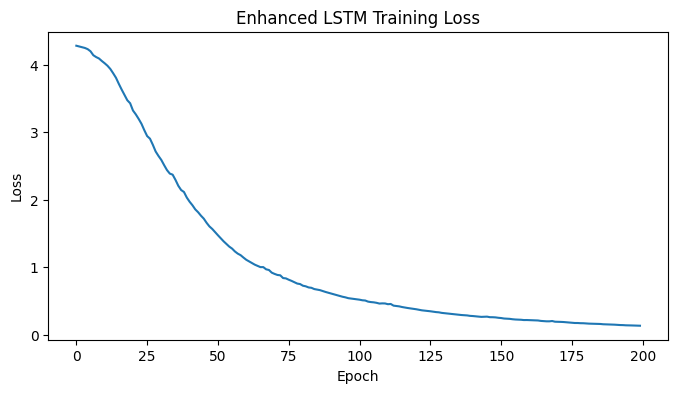

In [15]:
plt.figure(figsize=(8,4))

plt.plot(
    enhanced_history.history['loss']
)

plt.title("Enhanced LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# ✍️ Beginner Task 5: Generate 10 Words

The generated sequence length is increased from 5 words to 10 words to observe the model's ability to maintain contextual coherence over longer outputs.

In [16]:
def generate_custom_text(model, seed_text, next_words=10):

    tokenizer_used = task_tokenizer

    for _ in range(next_words):

        token_list = tokenizer_used.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=task_max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer_used.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [17]:
print(
    generate_custom_text(
        enhanced_lstm,
        "artificial intelligence",
        10
    )
)

artificial intelligence is widely used in healthcare finance education and cybersecurity operate


# 📊 Beginner Task Results

The following modifications were successfully implemented:

| Task | Status |
|--------|--------|
| Replace Corpus | ✅ Completed |
| Increase Embedding Dimension (32 → 64) | ✅ Completed |
| Increase Hidden Units (64 → 128) | ✅ Completed |
| Increase Epochs (100 → 200) | ✅ Completed |
| Generate 10 Words Instead of 5 | ✅ Completed |

### Observations

- Larger embedding dimensions provide richer word representations.
- Increasing hidden units improves model capacity.
- Additional training epochs reduce loss and improve learning.
- Longer generated sequences demonstrate the model's ability to retain contextual information.
- LSTM continues to perform well for sequential text generation tasks due to its memory mechanisms.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**